# 09. Coregistration diagnostics

Diagnóstico de outliers, bordes, máscara estable y métricas robustas extendidas.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import sys

REPO_PATH = Path("/content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo")
SRC_PATH = REPO_PATH / "src"

assert REPO_PATH.exists(), f"No existe: {REPO_PATH}"
assert SRC_PATH.exists(), f"No existe: {SRC_PATH}"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print("REPO_PATH:", REPO_PATH)
print("SRC_PATH :", SRC_PATH)

REPO_PATH: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo
SRC_PATH : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/src


In [4]:
!pip install xdem geoutils scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.3/177.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xdem
import geoutils as gu

from scipy.ndimage import binary_erosion

from projectio.paths import Paths

## Configuración

In [6]:
cfg = Paths(REPO_PATH)

BASE_EPOCH = "2025_B"
MASK_PATH = Path("/content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/Datos_Originales/mascaras/poligono_roca_estable/poligono_roca_estable.shp")

inventory_csv = cfg.qa() / "project_raster_inventory.csv"
coreg_results_csv = REPO_PATH / "outputs" / "coregistration_nk" / "coregistration_nk_results.csv"
batch_eval_csv = REPO_PATH / "outputs" / "coregistration_evaluation_batch" / "coreg_batch_comparison.csv"

DIAG_DIR = REPO_PATH / "outputs" / "coregistration_diagnostics"
FIG_DIR = DIAG_DIR / "figures"
MAP_DIR = DIAG_DIR / "maps"

DIAG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

assert MASK_PATH.exists(), f"No existe: {MASK_PATH}"
assert inventory_csv.exists(), f"No existe: {inventory_csv}"
assert coreg_results_csv.exists(), f"No existe: {coreg_results_csv}"

print("BASE_EPOCH       :", BASE_EPOCH)
print("MASK_PATH        :", MASK_PATH)
print("inventory_csv    :", inventory_csv)
print("coreg_results_csv:", coreg_results_csv)
print("batch_eval_csv   :", batch_eval_csv if batch_eval_csv.exists() else "No existe aún")
print("DIAG_DIR         :", DIAG_DIR)

BASE_EPOCH       : 2025_B
MASK_PATH        : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/Datos_Originales/mascaras/poligono_roca_estable/poligono_roca_estable.shp
inventory_csv    : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/qa/project_raster_inventory.csv
coreg_results_csv: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_nk/coregistration_nk_results.csv
batch_eval_csv   : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_evaluation_batch/coreg_batch_comparison.csv
DIAG_DIR         : /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics


## Carga de datos

In [7]:
inventory_df = pd.read_csv(inventory_csv)
results_df = pd.read_csv(coreg_results_csv)

print("Inventory rows:", len(inventory_df))
print("Results rows  :", len(results_df))

display(inventory_df.head())
display(results_df.head())

if batch_eval_csv.exists():
    batch_eval_df = pd.read_csv(batch_eval_csv)
    print("Batch eval rows:", len(batch_eval_df))
    display(batch_eval_df)
else:
    batch_eval_df = None

Inventory rows: 12
Results rows  : 5


,filename,epoch,product_type,source_path,path,exists,opened,error,crs,width,...,bounds_top,driver,valid_name,qa_exists,qa_opened,qa_has_crs,qa_has_dimensions,qa_has_bands,qa_valid_name,qa_ok
0,2017_DSM.tif,2017,dsm,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,8991,...,8225448.0,GTiff,True,True,True,True,True,True,True,True
1,2017_Ortho.tif,2017,ortho,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,8991,...,8225448.0,GTiff,True,True,True,True,True,True,True,True
2,2018_DSM.tif,2018,dsm,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,13010,...,8225539.0,GTiff,True,True,True,True,True,True,True,True
3,2018_Ortho.tif,2018,ortho,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,13010,...,8225539.0,GTiff,True,True,True,True,True,True,True,True
4,2020_DSM.tif,2020,dsm,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,True,True,NaN,EPSG:32719,2506,...,8225602.0,GTiff,True,True,True,True,True,True,True,True


,base_dem_path,target_dem_path,mask_vector_path,output_path,factor_giro,poly_order,status,epoch,base_epoch
0,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2017,2025_B
1,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2018,2025_B
2,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2020,2025_B
3,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2023,2025_B
4,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok,2025_A,2025_B


Batch eval rows: 5


,target_epoch,base_epoch,target_orig_path,target_corr_path,factor_giro,poly_order,n_before,n_after,mean_before,mean_after,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,error,quality_flag
0,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,1787617,1786630,40.044352,38.918251,...,40.044352,38.918251,3.616699,1.157227,True,True,False,True,False,improved_robust_but_outliers_remain
1,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,3507520,3502947,1412.587335,1420.177612,...,1412.587335,1420.177612,6.863281,0.207031,False,True,False,False,False,mixed
2,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,4116129,4107211,1626.154481,1630.960780,...,1626.154481,1630.960780,6.287109,2.517090,False,True,False,True,False,improved_robust_but_outliers_remain
3,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2594219,2594219,700.476374,700.457403,...,700.476374,700.457403,0.179199,0.163086,True,True,False,False,False,mixed
4,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,2458740,2458740,501.763221,501.774675,...,501.763221,501.774675,0.038086,0.049316,False,False,False,False,False,worsened


## Helpers

In [8]:
def get_dsm_path_for_epoch(inventory_df, epoch):
    row = inventory_df[
        (inventory_df["epoch"].astype(str).str.strip() == str(epoch).strip()) &
        (inventory_df["product_type"].astype(str).str.strip().str.lower() == "dsm") &
        (inventory_df["qa_ok"] == True)
    ].copy()
    assert len(row) == 1, f"No se encontró un único DSM válido para epoch={epoch}"
    return Path(row.iloc[0]["source_path"])


def get_ok_rows(results_df, base_epoch):
    tmp = results_df.copy()
    tmp["epoch"] = tmp["epoch"].astype(str).str.strip()
    tmp["base_epoch"] = tmp["base_epoch"].astype(str).str.strip()
    tmp["status"] = tmp["status"].astype(str).str.strip()

    ok_rows = tmp[
        (tmp["base_epoch"] == str(base_epoch).strip()) &
        (tmp["status"] == "ok")
    ].copy()

    ok_rows = ok_rows.sort_values(["epoch"]).reset_index(drop=True)
    return ok_rows


def clean_dh(values):
    arr = np.asarray(values, dtype="float64")
    arr = arr[np.isfinite(arr)]
    arr = arr[arr != -9999]
    return arr


def nmad(arr):
    arr = np.asarray(arr, dtype="float64")
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    med = np.nanmedian(arr)
    return 1.4826 * np.nanmedian(np.abs(arr - med))


def summarize_extended(arr, label):
    arr = np.asarray(arr, dtype="float64")
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {
            "label": label, "n": 0,
            "mean": np.nan, "median": np.nan, "std": np.nan, "nmad": np.nan,
            "min": np.nan, "max": np.nan,
            "p001": np.nan, "p01": np.nan, "p1": np.nan, "p2": np.nan,
            "p5": np.nan, "p25": np.nan, "p75": np.nan, "p95": np.nan,
            "p98": np.nan, "p99": np.nan, "p999": np.nan,
            "mean_abs": np.nan, "median_abs": np.nan
        }

    return {
        "label": label,
        "n": int(arr.size),
        "mean": float(np.nanmean(arr)),
        "median": float(np.nanmedian(arr)),
        "std": float(np.nanstd(arr)),
        "nmad": float(nmad(arr)),
        "min": float(np.nanmin(arr)),
        "max": float(np.nanmax(arr)),
        "p001": float(np.nanpercentile(arr, 0.1)),
        "p01": float(np.nanpercentile(arr, 1)),
        "p1": float(np.nanpercentile(arr, 1)),
        "p2": float(np.nanpercentile(arr, 2)),
        "p5": float(np.nanpercentile(arr, 5)),
        "p25": float(np.nanpercentile(arr, 25)),
        "p75": float(np.nanpercentile(arr, 75)),
        "p95": float(np.nanpercentile(arr, 95)),
        "p98": float(np.nanpercentile(arr, 98)),
        "p99": float(np.nanpercentile(arr, 99)),
        "p999": float(np.nanpercentile(arr, 99.9)),
        "mean_abs": float(np.nanmean(np.abs(arr))),
        "median_abs": float(np.nanmedian(np.abs(arr))),
    }


def clip_by_percentiles(arr, low, high):
    arr = np.asarray(arr, dtype="float64")
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return arr
    lo = np.nanpercentile(arr, low)
    hi = np.nanpercentile(arr, high)
    return arr[(arr >= lo) & (arr <= hi)]


def build_border_exclusion_mask(shape, border_px):
    h, w = shape
    mask = np.ones((h, w), dtype=bool)
    if border_px <= 0:
        return mask
    mask[:border_px, :] = False
    mask[-border_px:, :] = False
    mask[:, :border_px] = False
    mask[:, -border_px:] = False
    return mask


def bool_data_from_dem(dem):
    arr = np.asarray(dem.data)
    if arr.ndim == 3:
        arr = arr[0]
    return np.asarray(arr)


def valid_intersection_mask(base_dem, target_on_base):
    base_arr = bool_data_from_dem(base_dem)
    targ_arr = bool_data_from_dem(target_on_base)
    return np.isfinite(base_arr) & np.isfinite(targ_arr) & (base_arr != -9999) & (targ_arr != -9999)


def save_single_band_geotiff(array2d, reference_dem, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    arr = np.asarray(array2d)
    if arr.ndim == 3:
        arr = arr[0]

    profile = reference_dem.ds.profile.copy()
    profile.update(
        count=1,
        dtype="float32",
        nodata=np.nan,
        compress="deflate"
    )

    import rasterio
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(arr.astype("float32"), 1)


def summarize_pair(before_arr, after_arr, scenario_name):
    sb = summarize_extended(before_arr, f"before_{scenario_name}")
    sa = summarize_extended(after_arr, f"after_{scenario_name}")
    return {
        "scenario": scenario_name,
        "n_before": sb["n"],
        "n_after": sa["n"],
        "mean_before": sb["mean"],
        "mean_after": sa["mean"],
        "median_before": sb["median"],
        "median_after": sa["median"],
        "std_before": sb["std"],
        "std_after": sa["std"],
        "nmad_before": sb["nmad"],
        "nmad_after": sa["nmad"],
        "mean_abs_before": sb["mean_abs"],
        "mean_abs_after": sa["mean_abs"],
        "median_abs_before": sb["median_abs"],
        "median_abs_after": sa["median_abs"],
        "mean_improved": abs(sa["mean"]) < abs(sb["mean"]),
        "median_improved": abs(sa["median"]) < abs(sb["median"]),
        "std_improved": sa["std"] < sb["std"],
        "nmad_improved": sa["nmad"] < sb["nmad"],
    }

## DEM base y máscara estable

In [9]:
BASE_DEM_PATH = get_dsm_path_for_epoch(inventory_df, BASE_EPOCH)
assert BASE_DEM_PATH.exists(), f"No existe: {BASE_DEM_PATH}"

base_dem = xdem.DEM(BASE_DEM_PATH)
mask_vector = gu.Vector(MASK_PATH)
stable_mask_raw = mask_vector.create_mask(base_dem)
stable_mask_raw = np.asarray(stable_mask_raw)
if stable_mask_raw.ndim == 3:
    stable_mask_raw = stable_mask_raw[0]
stable_mask_raw = stable_mask_raw.astype(bool)
base_arr = bool_data_from_dem(base_dem)

print("BASE_DEM_PATH:", BASE_DEM_PATH)
print("Base shape   :", base_dem.shape)
print("Base res     :", base_dem.res)
print("Base crs     :", base_dem.crs)
print("Stable raw   :", int(np.sum(stable_mask_raw)))
print("Base finite  :", int(np.isfinite(base_arr).sum()))

BASE_DEM_PATH: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/data/raw/llojeta/2025_B/dsm/2025_B_DSM.tif
Base shape   : (2172, 2588)
Base res     : (0.5, 0.5)
Base crs     : EPSG:32719
Stable raw   : 1
Base finite  : 5621136


## Construcción de escenarios diagnósticos

In [10]:
border_px = 20
erosion_iters = 2

stable_mask_arr = np.asarray(stable_mask_raw)
if stable_mask_arr.ndim == 3:
    stable_mask_arr = stable_mask_arr[0]

stable_mask_arr = stable_mask_arr.astype(bool)

mask_valid_base = np.isfinite(base_arr) & (base_arr != -9999)
mask_border_ok = build_border_exclusion_mask(base_dem.shape, border_px)

mask_stable_eroded = binary_erosion(
    stable_mask_arr,
    iterations=erosion_iters
).astype(bool)

scenario_masks = {
    "stable_raw": stable_mask_arr & mask_valid_base,
    "stable_no_border": stable_mask_arr & mask_valid_base & mask_border_ok,
    "stable_eroded": mask_stable_eroded & mask_valid_base,
    "stable_eroded_no_border": mask_stable_eroded & mask_valid_base & mask_border_ok,
}

print("stable_mask_arr dtype :", stable_mask_arr.dtype)
print("stable_mask_arr shape :", stable_mask_arr.shape)
print("mask_valid_base shape :", mask_valid_base.shape)
print("mask_border_ok shape  :", mask_border_ok.shape)

for name, m in scenario_masks.items():
    print(name, int(np.sum(m)))

stable_mask_arr dtype : bool
stable_mask_arr shape : ()
mask_valid_base shape : (2172, 2588)
mask_border_ok shape  : (2172, 2588)
stable_raw 3391183
stable_no_border 3385172
stable_eroded 3391183
stable_eroded_no_border 3385172


## Filas OK a diagnosticar

In [11]:
ok_rows = get_ok_rows(results_df, BASE_EPOCH)
assert len(ok_rows) > 0, "No hay filas OK"

display(ok_rows[["epoch", "base_epoch", "output_path", "factor_giro", "poly_order", "status"]])

,epoch,base_epoch,output_path,factor_giro,poly_order,status
0,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
1,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
2,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
3,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok
4,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,-0.05,1,ok


## Diagnóstico principal por epoch

In [12]:
extended_stats_records = []
scenario_comparison_records = []
epoch_summary_records = []

for _, row in ok_rows.iterrows():
    epoch = str(row["epoch"]).strip()
    corr_path = Path(row["output_path"])

    print(f"\n[{epoch}] ==================================================")

    target_orig_path = get_dsm_path_for_epoch(inventory_df, epoch)
    assert target_orig_path.exists(), f"No existe target original: {target_orig_path}"
    assert corr_path.exists(), f"No existe target corregido: {corr_path}"

    target_orig = xdem.DEM(target_orig_path)
    target_corr = xdem.DEM(corr_path)

    target_orig_on_base = target_orig.reproject(base_dem)
    target_corr_on_base = target_corr.reproject(base_dem)

    dh_before = target_orig_on_base - base_dem
    dh_after = target_corr_on_base - base_dem

    dh_before_arr = bool_data_from_dem(dh_before)
    dh_after_arr = bool_data_from_dem(dh_after)

    valid_orig = valid_intersection_mask(base_dem, target_orig_on_base)
    valid_corr = valid_intersection_mask(base_dem, target_corr_on_base)
    valid_all = valid_orig & valid_corr

    print("valid_orig:", int(valid_orig.sum()))
    print("valid_corr:", int(valid_corr.sum()))
    print("valid_all :", int(valid_all.sum()))

    best_scenario = None
    best_nmad_after = np.inf

    for scenario_name, scenario_mask in scenario_masks.items():
        final_mask = scenario_mask & valid_all

        before_vals = clean_dh(dh_before_arr[final_mask])
        after_vals = clean_dh(dh_after_arr[final_mask])

        raw_pair = summarize_pair(before_vals, after_vals, f"{scenario_name}_raw")
        raw_pair.update({"target_epoch": epoch, "base_epoch": BASE_EPOCH})
        scenario_comparison_records.append(raw_pair)

        extended_stats_records.append({
            "target_epoch": epoch, "base_epoch": BASE_EPOCH,
            **summarize_extended(before_vals, f"before_{scenario_name}_raw")
        })
        extended_stats_records.append({
            "target_epoch": epoch, "base_epoch": BASE_EPOCH,
            **summarize_extended(after_vals, f"after_{scenario_name}_raw")
        })

        clip_1_99_before = clip_by_percentiles(before_vals, 1, 99)
        clip_1_99_after = clip_by_percentiles(after_vals, 1, 99)
        p199_pair = summarize_pair(clip_1_99_before, clip_1_99_after, f"{scenario_name}_clip1_99")
        p199_pair.update({"target_epoch": epoch, "base_epoch": BASE_EPOCH})
        scenario_comparison_records.append(p199_pair)

        extended_stats_records.append({
            "target_epoch": epoch, "base_epoch": BASE_EPOCH,
            **summarize_extended(clip_1_99_before, f"before_{scenario_name}_clip1_99")
        })
        extended_stats_records.append({
            "target_epoch": epoch, "base_epoch": BASE_EPOCH,
            **summarize_extended(clip_1_99_after, f"after_{scenario_name}_clip1_99")
        })

        clip_5_95_before = clip_by_percentiles(before_vals, 5, 95)
        clip_5_95_after = clip_by_percentiles(after_vals, 5, 95)
        p595_pair = summarize_pair(clip_5_95_before, clip_5_95_after, f"{scenario_name}_clip5_95")
        p595_pair.update({"target_epoch": epoch, "base_epoch": BASE_EPOCH})
        scenario_comparison_records.append(p595_pair)

        extended_stats_records.append({
            "target_epoch": epoch, "base_epoch": BASE_EPOCH,
            **summarize_extended(clip_5_95_before, f"before_{scenario_name}_clip5_95")
        })
        extended_stats_records.append({
            "target_epoch": epoch, "base_epoch": BASE_EPOCH,
            **summarize_extended(clip_5_95_after, f"after_{scenario_name}_clip5_95")
        })

        if np.isfinite(raw_pair["nmad_after"]) and raw_pair["nmad_after"] < best_nmad_after:
            best_nmad_after = raw_pair["nmad_after"]
            best_scenario = scenario_name

    epoch_summary_records.append({
        "target_epoch": epoch,
        "base_epoch": BASE_EPOCH,
        "target_orig_path": str(target_orig_path),
        "target_corr_path": str(corr_path),
        "best_raw_scenario_by_nmad_after": best_scenario,
        "best_raw_nmad_after": best_nmad_after,
        "valid_all_pixels": int(valid_all.sum()),
    })


[2017] ==================================================
valid_orig: 1775641
valid_corr: 1774289
valid_all : 1766731

[2018] ==================================================
valid_orig: 2534955
valid_corr: 2522302
valid_all : 2510997

[2020] ==================================================
valid_orig: 2783668
valid_corr: 2771784
valid_all : 2747295

[2023] ==================================================
valid_orig: 2237762
valid_corr: 2237762
valid_all : 2237762

[2025_A] ==================================================
valid_orig: 2220447
valid_corr: 2220447
valid_all : 2220447


## Tablas diagnósticas

In [13]:
extended_stats_df = pd.DataFrame(extended_stats_records)
scenario_comparison_df = pd.DataFrame(scenario_comparison_records)
epoch_summary_df = pd.DataFrame(epoch_summary_records)

print("extended_stats_df       :", len(extended_stats_df))
print("scenario_comparison_df  :", len(scenario_comparison_df))
print("epoch_summary_df        :", len(epoch_summary_df))

display(epoch_summary_df)
display(scenario_comparison_df.head(30))
display(extended_stats_df.head(30))

extended_stats_df       : 120
scenario_comparison_df  : 60
epoch_summary_df        : 5


,target_epoch,base_epoch,target_orig_path,target_corr_path,best_raw_scenario_by_nmad_after,best_raw_nmad_after,valid_all_pixels
0,2017,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,stable_raw,3.681163,1766731
1,2018,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,stable_raw,5.250634,2510997
2,2020,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,stable_no_border,6.162418,2747295
3,2023,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,stable_raw,0.323595,2237762
4,2025_A,2025_B,/content/drive/MyDrive/geo_projects/llojeta-gl...,/content/drive/MyDrive/geo_projects/llojeta-gl...,stable_raw,0.097006,2220447


,scenario,n_before,n_after,mean_before,mean_after,median_before,median_after,std_before,std_after,nmad_before,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,target_epoch,base_epoch
0,stable_raw_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B
1,stable_raw_clip1_99,1731399,1731401,5.526326,3.306667,3.594238,1.130371,5.122027,4.963112,4.385542,...,5.726471,4.134896,3.629395,2.000977,True,True,True,True,2017,2025_B
2,stable_raw_clip5_95,1590081,1590074,5.347439,3.103891,3.594238,1.130371,4.455482,4.313270,3.916438,...,5.380257,3.678666,3.594238,1.678711,True,True,True,True,2017,2025_B
3,stable_no_border_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B
4,stable_no_border_clip1_99,1731399,1731401,5.526326,3.306667,3.594238,1.130371,5.122027,4.963112,4.385542,...,5.726471,4.134896,3.629395,2.000977,True,True,True,True,2017,2025_B
5,stable_no_border_clip5_95,1590081,1590074,5.347439,3.103891,3.594238,1.130371,4.455482,4.313270,3.916438,...,5.380257,3.678666,3.594238,1.678711,True,True,True,True,2017,2025_B
6,stable_eroded_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B
7,stable_eroded_clip1_99,1731399,1731401,5.526326,3.306667,3.594238,1.130371,5.122027,4.963112,4.385542,...,5.726471,4.134896,3.629395,2.000977,True,True,True,True,2017,2025_B
8,stable_eroded_clip5_95,1590081,1590074,5.347439,3.103891,3.594238,1.130371,4.455482,4.313270,3.916438,...,5.380257,3.678666,3.594238,1.678711,True,True,True,True,2017,2025_B
9,stable_eroded_no_border_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B


,target_epoch,base_epoch,label,n,mean,median,std,nmad,min,max,...,p2,p5,p25,p75,p95,p98,p99,p999,mean_abs,median_abs
0,2017,2025_B,before_stable_raw_raw,1766731,5.579150,3.594238,5.445805,4.517297,-15.051270,26.665039,...,-2.679688,-0.894043,1.587402,9.741699,15.544922,18.002637,19.924316,24.114746,5.886564,3.757812
1,2017,2025_B,after_stable_raw_raw,1766731,3.371101,1.130371,5.271004,3.681163,-17.751953,23.917969,...,-4.191895,-2.733398,-0.370605,7.314941,13.296875,15.662598,17.555664,21.814453,4.313142,2.097168
2,2017,2025_B,before_stable_raw_clip1_99,1731399,5.526326,3.594238,5.122027,4.385542,-4.108398,19.924316,...,-1.946777,-0.585449,1.627930,9.654297,15.123535,16.985371,18.027344,19.705078,5.726471,3.629395
3,2017,2025_B,after_stable_raw_clip1_99,1731401,3.306667,1.130371,4.963112,3.555200,-5.219727,17.555664,...,-3.578613,-2.463379,-0.338379,7.223145,12.840332,14.658691,15.690918,17.356445,4.134896,2.000977
4,2017,2025_B,before_stable_raw_clip5_95,1590081,5.347439,3.594238,4.455482,3.916438,-0.894043,15.544922,...,-0.364258,0.038574,1.782715,9.285645,13.690918,14.699707,15.124023,15.503418,5.380257,3.594238
5,2017,2025_B,after_stable_raw_clip5_95,1590074,3.103891,1.130371,4.313270,3.117224,-2.733398,13.296875,...,-2.231934,-1.740723,-0.216187,6.864746,11.454102,12.425293,12.840820,13.247559,3.678666,1.678711
6,2017,2025_B,before_stable_no_border_raw,1766731,5.579150,3.594238,5.445805,4.517297,-15.051270,26.665039,...,-2.679688,-0.894043,1.587402,9.741699,15.544922,18.002637,19.924316,24.114746,5.886564,3.757812
7,2017,2025_B,after_stable_no_border_raw,1766731,3.371101,1.130371,5.271004,3.681163,-17.751953,23.917969,...,-4.191895,-2.733398,-0.370605,7.314941,13.296875,15.662598,17.555664,21.814453,4.313142,2.097168
8,2017,2025_B,before_stable_no_border_clip1_99,1731399,5.526326,3.594238,5.122027,4.385542,-4.108398,19.924316,...,-1.946777,-0.585449,1.627930,9.654297,15.123535,16.985371,18.027344,19.705078,5.726471,3.629395
9,2017,2025_B,after_stable_no_border_clip1_99,1731401,3.306667,1.130371,4.963112,3.555200,-5.219727,17.555664,...,-3.578613,-2.463379,-0.338379,7.223145,12.840332,14.658691,15.690918,17.356445,4.134896,2.000977


## Salida clave 1: comparación de escenarios raw

In [14]:
raw_scenarios_df = scenario_comparison_df[
    scenario_comparison_df["scenario"].str.endswith("_raw")
].copy()

raw_scenarios_pivot = raw_scenarios_df.sort_values(
    ["target_epoch", "scenario"]
).reset_index(drop=True)

display(raw_scenarios_pivot)

,scenario,n_before,n_after,mean_before,mean_after,median_before,median_after,std_before,std_after,nmad_before,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,target_epoch,base_epoch
0,stable_eroded_no_border_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B
1,stable_eroded_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B
2,stable_no_border_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B
3,stable_raw_raw,1766731,1766731,5.579150,3.371101,3.594238,1.130371,5.445805,5.271004,4.517297,...,5.886564,4.313142,3.757812,2.097168,True,True,True,True,2017,2025_B
4,stable_eroded_no_border_raw,2509211,2509211,4.959108,-2.106565,4.212402,-2.005859,4.913257,5.272433,4.902425,...,5.358095,4.529062,4.271973,3.856934,True,True,False,False,2018,2025_B
5,stable_eroded_raw,2510997,2510997,4.954901,-2.107840,4.209473,-2.006836,4.914600,5.271650,4.906045,...,5.355789,4.528660,4.269043,3.856445,True,True,False,False,2018,2025_B
6,stable_no_border_raw,2509211,2509211,4.959108,-2.106565,4.212402,-2.005859,4.913257,5.272433,4.902425,...,5.358095,4.529062,4.271973,3.856934,True,True,False,False,2018,2025_B
7,stable_raw_raw,2510997,2510997,4.954901,-2.107840,4.209473,-2.006836,4.914600,5.271650,4.906045,...,5.355789,4.528660,4.269043,3.856445,True,True,False,False,2018,2025_B
8,stable_eroded_no_border_raw,2743090,2743090,1.828436,-0.908376,1.689941,-0.716797,6.388134,5.858963,7.591086,...,5.368667,4.744086,4.323730,4.173340,True,True,True,True,2020,2025_B
9,stable_eroded_raw,2747295,2747295,1.815556,-0.919929,1.685059,-0.723145,6.393502,5.866284,7.597601,...,5.371073,4.751196,4.327637,4.181152,True,True,True,True,2020,2025_B


## Salida clave 2: comparación de clipping

In [15]:
clip_compare_df = scenario_comparison_df[
    scenario_comparison_df["scenario"].str.contains("clip")
].copy()

display(clip_compare_df.sort_values(["target_epoch", "scenario"]).reset_index(drop=True))

,scenario,n_before,n_after,mean_before,mean_after,median_before,median_after,std_before,std_after,nmad_before,...,mean_abs_before,mean_abs_after,median_abs_before,median_abs_after,mean_improved,median_improved,std_improved,nmad_improved,target_epoch,base_epoch
0,stable_eroded_clip1_99,1731399,1731401,5.526326,3.306667,3.594238,1.130371,5.122027,4.963112,4.385542,...,5.726471,4.134896,3.629395,2.000977,True,True,True,True,2017,2025_B
1,stable_eroded_clip5_95,1590081,1590074,5.347439,3.103891,3.594238,1.130371,4.455482,4.313270,3.916438,...,5.380257,3.678666,3.594238,1.678711,True,True,True,True,2017,2025_B
2,stable_eroded_no_border_clip1_99,1731399,1731401,5.526326,3.306667,3.594238,1.130371,5.122027,4.963112,4.385542,...,5.726471,4.134896,3.629395,2.000977,True,True,True,True,2017,2025_B
3,stable_eroded_no_border_clip5_95,1590081,1590074,5.347439,3.103891,3.594238,1.130371,4.455482,4.313270,3.916438,...,5.380257,3.678666,3.594238,1.678711,True,True,True,True,2017,2025_B
4,stable_no_border_clip1_99,1731399,1731401,5.526326,3.306667,3.594238,1.130371,5.122027,4.963112,4.385542,...,5.726471,4.134896,3.629395,2.000977,True,True,True,True,2017,2025_B
5,stable_no_border_clip5_95,1590081,1590074,5.347439,3.103891,3.594238,1.130371,4.455482,4.313270,3.916438,...,5.380257,3.678666,3.594238,1.678711,True,True,True,True,2017,2025_B
6,stable_raw_clip1_99,1731399,1731401,5.526326,3.306667,3.594238,1.130371,5.122027,4.963112,4.385542,...,5.726471,4.134896,3.629395,2.000977,True,True,True,True,2017,2025_B
7,stable_raw_clip5_95,1590081,1590074,5.347439,3.103891,3.594238,1.130371,4.455482,4.313270,3.916438,...,5.380257,3.678666,3.594238,1.678711,True,True,True,True,2017,2025_B
8,stable_eroded_clip1_99,2460783,2460782,4.898297,-2.165191,4.208984,-2.006836,4.571648,4.931366,4.779358,...,5.198371,4.342291,4.208984,3.746094,True,True,False,False,2018,2025_B
9,stable_eroded_clip5_95,2259910,2259945,4.717037,-2.286739,4.209473,-2.006836,3.905845,4.204248,4.301567,...,4.870007,3.856677,4.209473,3.322266,True,True,False,False,2018,2025_B


## Salida clave 3: extremos de distribución

In [16]:
extremes_df = extended_stats_df[
    extended_stats_df["label"].str.contains("raw")
].copy()

extremes_df = extremes_df[[
    "target_epoch", "base_epoch", "label", "n", "mean", "median", "std", "nmad",
    "min", "p001", "p01", "p1", "p5", "p95", "p99", "p999", "max"
]].sort_values(["target_epoch", "label"]).reset_index(drop=True)

display(extremes_df)

,target_epoch,base_epoch,label,n,mean,median,std,nmad,min,p001,p01,p1,p5,p95,p99,p999,max
0,2017,2025_B,after_stable_eroded_no_border_raw,1766731,3.371101,1.130371,5.271004,3.681163,-17.751953,-8.065073,-5.219727,-5.219727,-2.733398,13.296875,17.555664,21.814453,23.917969
1,2017,2025_B,after_stable_eroded_raw,1766731,3.371101,1.130371,5.271004,3.681163,-17.751953,-8.065073,-5.219727,-5.219727,-2.733398,13.296875,17.555664,21.814453,23.917969
2,2017,2025_B,after_stable_no_border_raw,1766731,3.371101,1.130371,5.271004,3.681163,-17.751953,-8.065073,-5.219727,-5.219727,-2.733398,13.296875,17.555664,21.814453,23.917969
3,2017,2025_B,after_stable_raw_clip1_99,1731401,3.306667,1.130371,4.963112,3.555200,-5.219727,-5.066699,-4.206543,-4.206543,-2.463379,12.840332,15.690918,17.356445,17.555664
4,2017,2025_B,after_stable_raw_clip5_95,1590074,3.103891,1.130371,4.313270,3.117224,-2.733398,-2.704590,-2.463379,-2.463379,-1.740723,11.454102,12.840820,13.247559,13.296875
5,2017,2025_B,after_stable_raw_raw,1766731,3.371101,1.130371,5.271004,3.681163,-17.751953,-8.065073,-5.219727,-5.219727,-2.733398,13.296875,17.555664,21.814453,23.917969
6,2017,2025_B,before_stable_eroded_no_border_raw,1766731,5.579150,3.594238,5.445805,4.517297,-15.051270,-7.337891,-4.108398,-4.108398,-0.894043,15.544922,19.924316,24.114746,26.665039
7,2017,2025_B,before_stable_eroded_raw,1766731,5.579150,3.594238,5.445805,4.517297,-15.051270,-7.337891,-4.108398,-4.108398,-0.894043,15.544922,19.924316,24.114746,26.665039
8,2017,2025_B,before_stable_no_border_raw,1766731,5.579150,3.594238,5.445805,4.517297,-15.051270,-7.337891,-4.108398,-4.108398,-0.894043,15.544922,19.924316,24.114746,26.665039
9,2017,2025_B,before_stable_raw_clip1_99,1731399,5.526326,3.594238,5.122027,4.385542,-4.108398,-3.927734,-2.701172,-2.701172,-0.585449,15.123535,18.027344,19.705078,19.924316


## Histogramas por epoch

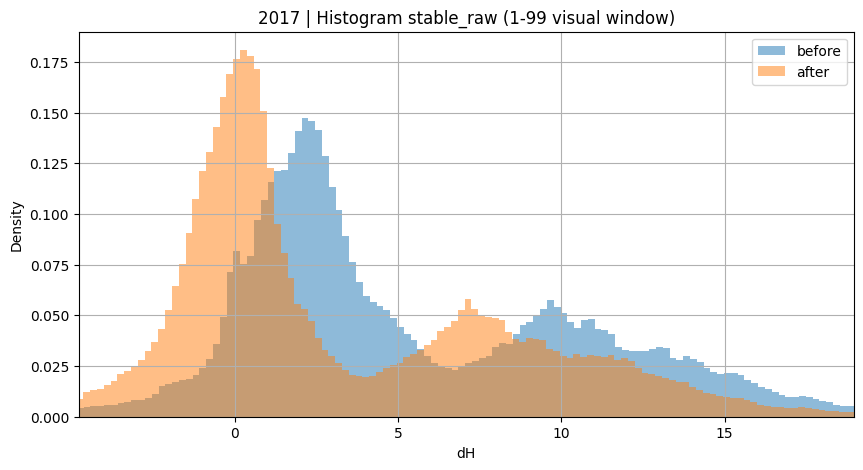

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2017_hist_stable_raw.png


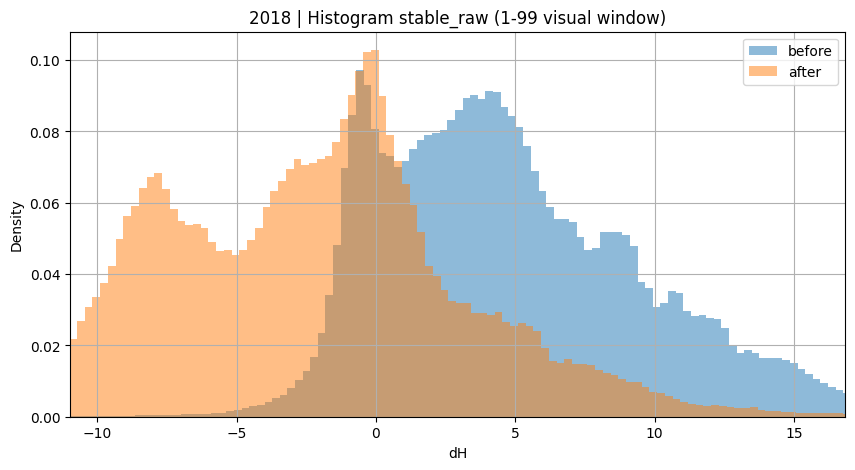

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2018_hist_stable_raw.png


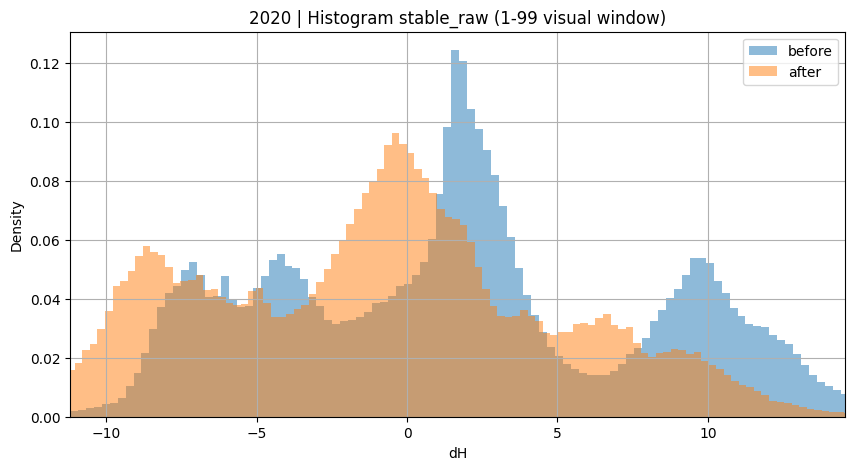

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2020_hist_stable_raw.png


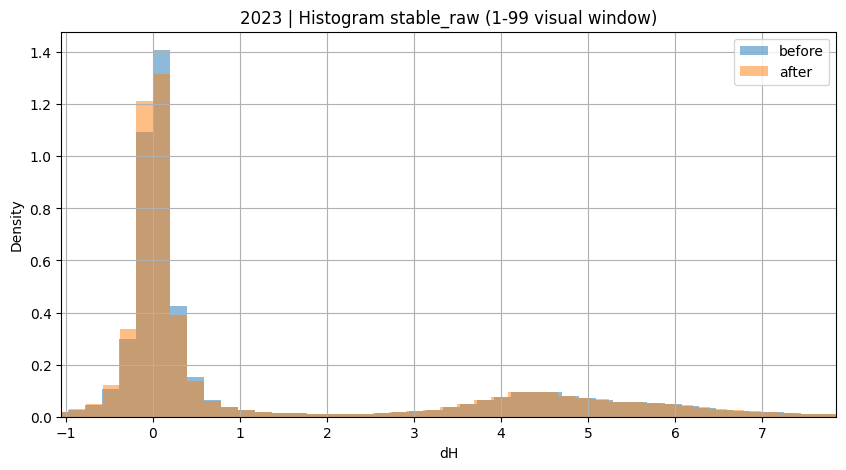

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2023_hist_stable_raw.png


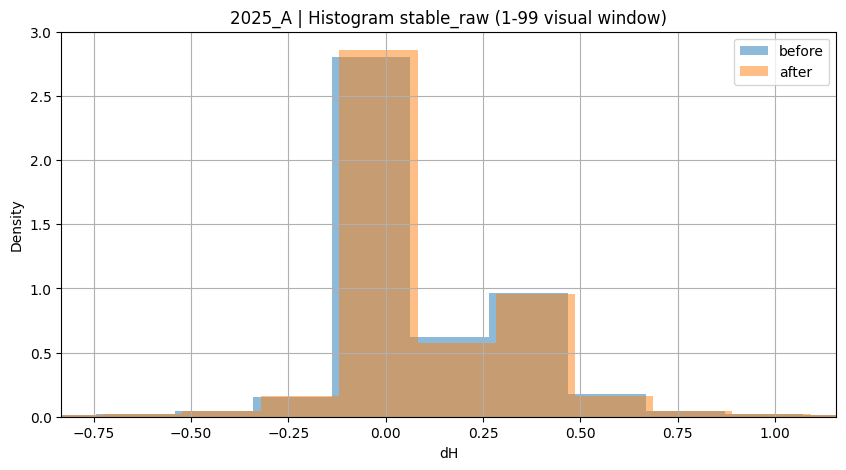

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2025_A_hist_stable_raw.png


In [17]:
epochs = list(epoch_summary_df["target_epoch"].astype(str))

for epoch in epochs:
    raw_epoch = scenario_comparison_df[
        (scenario_comparison_df["target_epoch"] == epoch) &
        (scenario_comparison_df["scenario"] == "stable_raw_raw")
    ]
    if len(raw_epoch) == 0:
        continue

    target_orig_path = get_dsm_path_for_epoch(inventory_df, epoch)
    corr_path = Path(ok_rows[ok_rows["epoch"].astype(str) == epoch].iloc[0]["output_path"])

    target_orig = xdem.DEM(target_orig_path).reproject(base_dem)
    target_corr = xdem.DEM(corr_path).reproject(base_dem)

    dh_before_arr = bool_data_from_dem(target_orig - base_dem)
    dh_after_arr = bool_data_from_dem(target_corr - base_dem)

    valid_all = valid_intersection_mask(base_dem, target_orig) & valid_intersection_mask(base_dem, target_corr)
    mask = scenario_masks["stable_raw"] & valid_all

    before_vals = clean_dh(dh_before_arr[mask])
    after_vals = clean_dh(dh_after_arr[mask])

    fig = plt.figure(figsize=(10, 5))
    plt.hist(before_vals, bins=200, alpha=0.5, label="before", density=True)
    plt.hist(after_vals, bins=200, alpha=0.5, label="after", density=True)
    plt.xlim(np.nanpercentile(np.r_[before_vals, after_vals], 1), np.nanpercentile(np.r_[before_vals, after_vals], 99))
    plt.title(f"{epoch} | Histogram stable_raw (1-99 visual window)")
    plt.xlabel("dH")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    out_png = FIG_DIR / f"{epoch}_hist_stable_raw.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Guardado:", out_png)

## Mapas dH before/after y diferencia de mejora


[2017] ==========================================


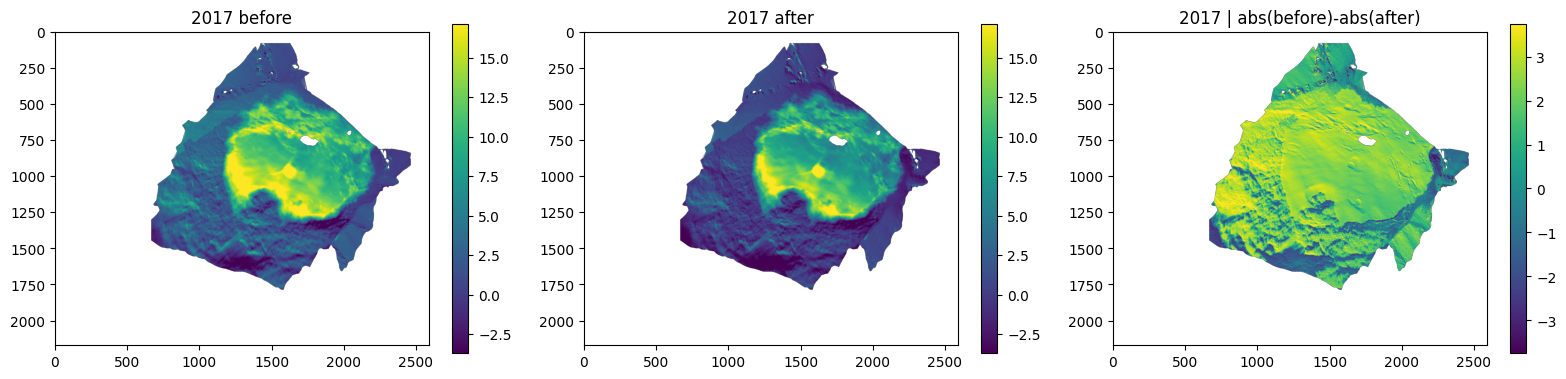

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2017_maps_stable_raw.png
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2017_dh_before_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2017_dh_after_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2017_improvement_abs_stable_raw.tif

[2018] ==========================================


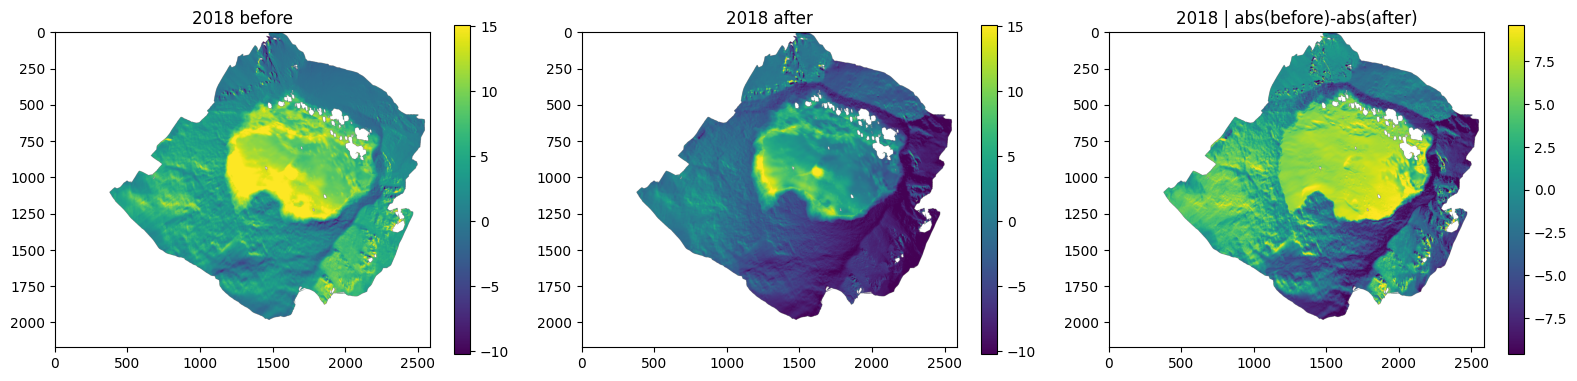

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2018_maps_stable_raw.png
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2018_dh_before_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2018_dh_after_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2018_improvement_abs_stable_raw.tif

[2020] ==========================================


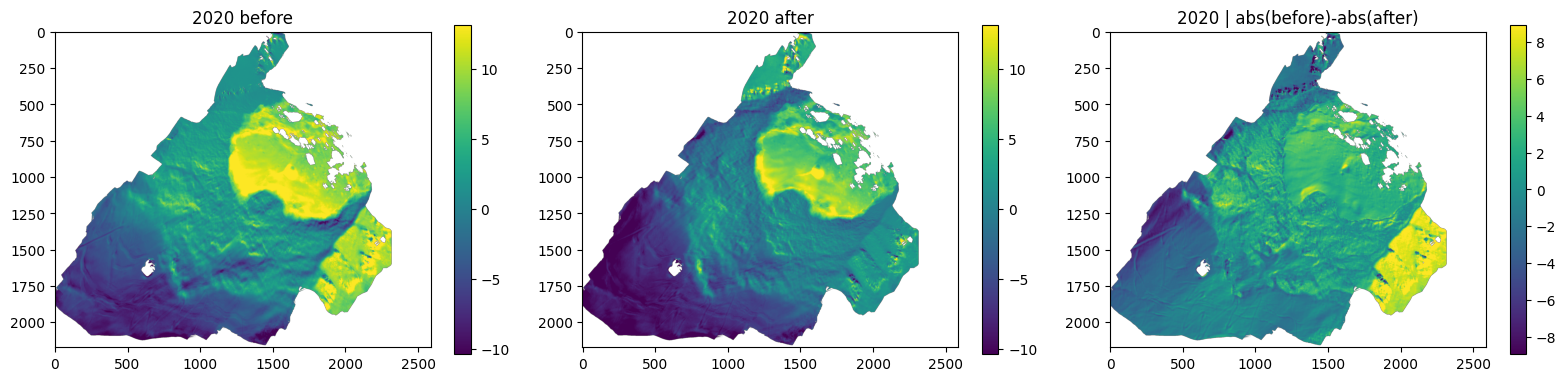

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2020_maps_stable_raw.png
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2020_dh_before_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2020_dh_after_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2020_improvement_abs_stable_raw.tif

[2023] ==========================================


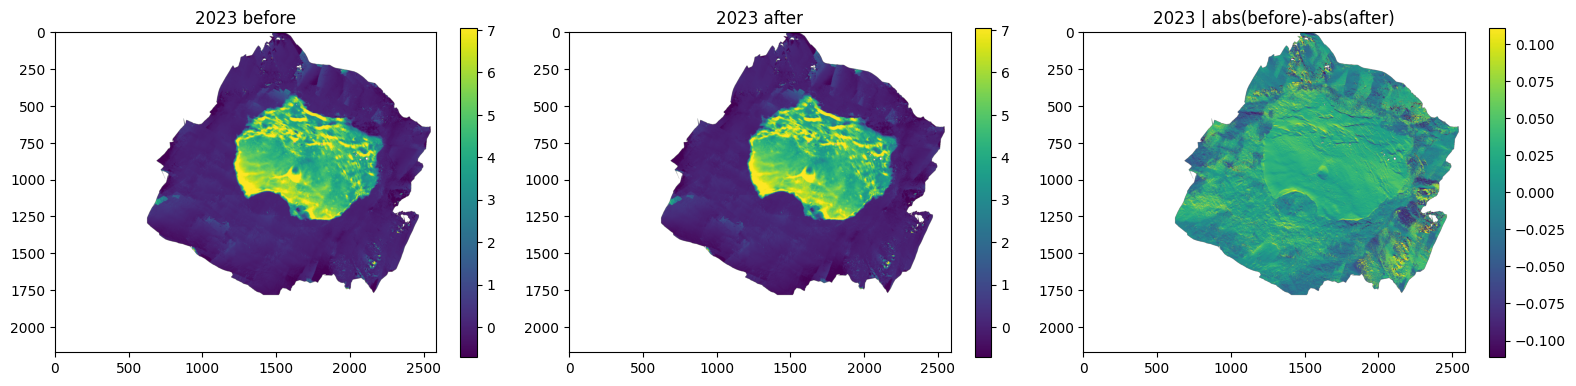

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2023_maps_stable_raw.png
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2023_dh_before_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2023_dh_after_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2023_improvement_abs_stable_raw.tif

[2025_A] ==========================================


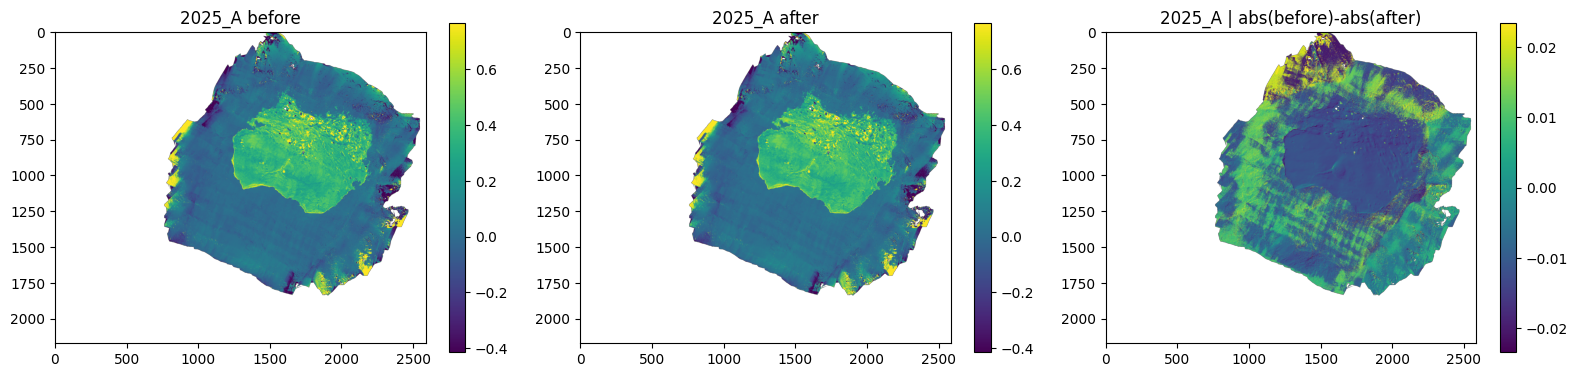

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/figures/2025_A_maps_stable_raw.png
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2025_A_dh_before_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2025_A_dh_after_stable_raw.tif
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/maps/2025_A_improvement_abs_stable_raw.tif


In [18]:
# =========================
# Mapas dH before/after y diferencia de mejora
# versión robusta e independiente de epoch_summary_df
# =========================

if "ok_rows" not in globals():
    raise RuntimeError("ok_rows no existe. Ejecuta primero la celda 'Filas OK a diagnosticar'.")

if "base_dem" not in globals():
    raise RuntimeError("base_dem no existe. Ejecuta primero la celda 'DEM base y máscara estable'.")

if "scenario_masks" not in globals():
    raise RuntimeError("scenario_masks no existe. Ejecuta primero la celda 'Construcción de escenarios diagnósticos'.")

epochs_list = list(ok_rows["epoch"].astype(str).str.strip().unique())

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def _write_geotiff(arr2d, out_path, ref_dem):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    arr2d = np.asarray(arr2d)
    if arr2d.ndim == 3:
        arr2d = arr2d[0]
    arr2d = arr2d.astype("float32")

    transform = getattr(ref_dem, "transform", None)
    crs = getattr(ref_dem, "crs", None)

    if transform is None:
        raise AttributeError("base_dem no expone atributo 'transform'")
    if crs is None:
        raise AttributeError("base_dem no expone atributo 'crs'")

    height, width = arr2d.shape

    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype="float32",
        crs=crs,
        transform=transform,
        nodata=np.nan,
        compress="deflate",
    ) as dst:
        dst.write(arr2d, 1)

for epoch in epochs_list:
    print(f"\n[{epoch}] ==========================================")

    target_orig_path = get_dsm_path_for_epoch(inventory_df, epoch)
    corr_path = Path(
        ok_rows[ok_rows["epoch"].astype(str).str.strip() == epoch]
        .iloc[0]["output_path"]
    )

    target_orig = xdem.DEM(target_orig_path).reproject(base_dem)
    target_corr = xdem.DEM(corr_path).reproject(base_dem)

    dh_before = target_orig - base_dem
    dh_after = target_corr - base_dem

    dh_before_arr = bool_data_from_dem(dh_before).astype("float32")
    dh_after_arr = bool_data_from_dem(dh_after).astype("float32")
    improvement_arr = np.abs(dh_before_arr) - np.abs(dh_after_arr)

    valid_all = (
        valid_intersection_mask(base_dem, target_orig) &
        valid_intersection_mask(base_dem, target_corr)
    )

    scenario_mask = (
        np.asarray(scenario_masks["stable_raw"]).astype(bool) &
        np.asarray(valid_all).astype(bool)
    )

    before_masked = np.where(scenario_mask, dh_before_arr, np.nan).astype("float32")
    after_masked = np.where(scenario_mask, dh_after_arr, np.nan).astype("float32")
    improvement_masked = np.where(scenario_mask, improvement_arr, np.nan).astype("float32")

    # Export GeoTIFF
    before_tif = MAP_DIR / f"{epoch}_dh_before_stable_raw.tif"
    after_tif = MAP_DIR / f"{epoch}_dh_after_stable_raw.tif"
    improvement_tif = MAP_DIR / f"{epoch}_improvement_abs_stable_raw.tif"

    _write_geotiff(before_masked, before_tif, base_dem)
    _write_geotiff(after_masked, after_tif, base_dem)
    _write_geotiff(improvement_masked, improvement_tif, base_dem)

    before_valid = before_masked[np.isfinite(before_masked)]
    after_valid = after_masked[np.isfinite(after_masked)]
    improvement_valid = improvement_masked[np.isfinite(improvement_masked)]

    if len(before_valid) == 0 or len(after_valid) == 0:
        print(f"[{epoch}] Sin valores válidos para visualización.")
        continue

    combined = np.r_[before_valid, after_valid]
    vmin = np.nanpercentile(combined, 2)
    vmax = np.nanpercentile(combined, 98)

    if len(improvement_valid) > 0:
        imp_lim = np.nanpercentile(np.abs(improvement_valid), 98)
        if not np.isfinite(imp_lim) or imp_lim == 0:
            imp_lim = 1.0
    else:
        imp_lim = 1.0

    fig = plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(before_masked, vmin=vmin, vmax=vmax)
    plt.title(f"{epoch} before")
    plt.colorbar(shrink=0.7)

    plt.subplot(1, 3, 2)
    plt.imshow(after_masked, vmin=vmin, vmax=vmax)
    plt.title(f"{epoch} after")
    plt.colorbar(shrink=0.7)

    plt.subplot(1, 3, 3)
    plt.imshow(improvement_masked, vmin=-imp_lim, vmax=imp_lim)
    plt.title(f"{epoch} | abs(before)-abs(after)")
    plt.colorbar(shrink=0.7)

    out_png = FIG_DIR / f"{epoch}_maps_stable_raw.png"
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Guardado:", out_png)
    print("Guardado:", before_tif)
    print("Guardado:", after_tif)
    print("Guardado:", improvement_tif)

## Resumen de decisión preliminar

In [19]:
decision_records = []

for epoch in sorted(scenario_comparison_df["target_epoch"].astype(str).unique()):
    sub = scenario_comparison_df[scenario_comparison_df["target_epoch"].astype(str) == epoch].copy()

    raw_sub = sub[sub["scenario"].str.endswith("_raw")].copy()
    clip_sub = sub[sub["scenario"].str.contains("clip1_99")].copy()

    best_raw = raw_sub.sort_values(["nmad_after", "median_abs_after"], ascending=[True, True]).iloc[0]
    best_clip = clip_sub.sort_values(["nmad_after", "median_abs_after"], ascending=[True, True]).iloc[0]

    outlier_sensitivity = (
        abs(best_raw["mean_after"] - best_clip["mean_after"])
        if np.isfinite(best_raw["mean_after"]) and np.isfinite(best_clip["mean_after"])
        else np.nan
    )

    decision_records.append({
        "target_epoch": epoch,
        "best_raw_scenario": best_raw["scenario"],
        "best_raw_nmad_after": best_raw["nmad_after"],
        "best_raw_median_abs_after": best_raw["median_abs_after"],
        "best_clip1_99_scenario": best_clip["scenario"],
        "best_clip1_99_nmad_after": best_clip["nmad_after"],
        "best_clip1_99_median_abs_after": best_clip["median_abs_after"],
        "outlier_sensitivity_mean_after": outlier_sensitivity,
        "raw_mean_after": best_raw["mean_after"],
        "clip1_99_mean_after": best_clip["mean_after"],
    })

decision_df = pd.DataFrame(decision_records)
display(decision_df.sort_values("target_epoch").reset_index(drop=True))

,target_epoch,best_raw_scenario,best_raw_nmad_after,best_raw_median_abs_after,best_clip1_99_scenario,best_clip1_99_nmad_after,best_clip1_99_median_abs_after,outlier_sensitivity_mean_after,raw_mean_after,clip1_99_mean_after
0,2017,stable_raw_raw,3.681163,2.097168,stable_raw_clip1_99,3.555200,2.000977,0.064434,3.371101,3.306667
1,2018,stable_raw_raw,5.250634,3.856445,stable_raw_clip1_99,5.105125,3.746094,0.057351,-2.107840,-2.165191
2,2020,stable_no_border_raw,6.162418,4.173340,stable_no_border_clip1_99,5.968044,4.028320,0.039816,-0.908376,-0.948192
3,2023,stable_no_border_raw,0.323595,0.201660,stable_no_border_clip1_99,0.311288,0.193359,0.044931,1.288092,1.243161
4,2025_A,stable_raw_raw,0.097006,0.062988,stable_raw_clip1_99,0.093386,0.060547,0.000001,0.114644,0.114643


## Exportación

In [20]:
extended_stats_csv = DIAG_DIR / "coreg_diag_extended_stats.csv"
scenario_comparison_csv = DIAG_DIR / "coreg_diag_scenario_comparison.csv"
epoch_summary_csv = DIAG_DIR / "coreg_diag_epoch_summary.csv"
decision_csv = DIAG_DIR / "coreg_diag_decision_table.csv"

extended_stats_df.to_csv(extended_stats_csv, index=False, encoding="utf-8")
scenario_comparison_df.to_csv(scenario_comparison_csv, index=False, encoding="utf-8")
epoch_summary_df.to_csv(epoch_summary_csv, index=False, encoding="utf-8")
decision_df.to_csv(decision_csv, index=False, encoding="utf-8")

summary = {
    "base_epoch": BASE_EPOCH,
    "epochs_diagnosed": sorted(scenario_comparison_df["target_epoch"].astype(str).unique().tolist()),
    "scenario_count": int(len(scenario_comparison_df)),
    "border_px": border_px,
    "erosion_iters": erosion_iters,
    "exports": {
        "extended_stats_csv": str(extended_stats_csv),
        "scenario_comparison_csv": str(scenario_comparison_csv),
        "epoch_summary_csv": str(epoch_summary_csv),
        "decision_csv": str(decision_csv),
        "figure_dir": str(FIG_DIR),
        "map_dir": str(MAP_DIR),
    }
}

summary_json = DIAG_DIR / "coreg_diag_summary.json"
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Guardado:", extended_stats_csv)
print("Guardado:", scenario_comparison_csv)
print("Guardado:", epoch_summary_csv)
print("Guardado:", decision_csv)
print("Guardado:", summary_json)

Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/coreg_diag_extended_stats.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/coreg_diag_scenario_comparison.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/coreg_diag_epoch_summary.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/coreg_diag_decision_table.csv
Guardado: /content/drive/MyDrive/geo_projects/llojeta-glacier-analysis/repo/outputs/coregistration_diagnostics/coreg_diag_summary.json


## Celdas que debes evaluar para decidir el siguiente paso

1. **"Salida clave 1: comparación de escenarios raw"**
   - mirar si `stable_no_border` o `stable_eroded_no_border` reducen fuerte `mean_after`, `std_after`, `nmad_after` respecto a `stable_raw`.
   - si mejoran mucho, el problema principal está en bordes o contaminación de máscara.

2. **"Salida clave 2: comparación de clipping"**
   - comparar `raw` vs `clip1_99` y `clip5_95`.
   - si el `mean_after` cae drásticamente con clipping pero `median_after` cambia poco, el problema es dominado por outliers.

3. **"Salida clave 3: extremos de distribución"**
   - revisar `min`, `max`, `p001`, `p999`, `p99`.
   - si aparecen colas extremas absurdas, hay contaminación espacial severa.

4. **"Histogramas por epoch"**
   - verificar si la masa central mejora y las colas siguen largas.
   - eso distinguirá corrección parcial real vs falla completa.

5. **"Mapas dH before/after y diferencia de mejora"**
   - revisar si los outliers se concentran en bordes, manchas o bloques.
   - si se localizan espacialmente, la solución puede ser de máscara/evaluación y no de coregistro.

6. **"Resumen de decisión preliminar"**
   - esta tabla resume sensibilidad a outliers y escenarios ganadores por epoch.
   - úsala para decidir entre:
     - refinar máscara/evaluación,
     - aceptar algunos epochs y rechazar otros,
     - o volver a tocar la metodología de coregistro.

In [21]:
print("=== CELDAS CLAVE A REVISAR ===")
print("1) Salida clave 1: comparación de escenarios raw")
print("2) Salida clave 2: comparación de clipping")
print("3) Salida clave 3: extremos de distribución")
print("4) Histogramas por epoch")
print("5) Mapas dH before/after y diferencia de mejora")
print("6) Resumen de decisión preliminar")

=== CELDAS CLAVE A REVISAR ===
1) Salida clave 1: comparación de escenarios raw
2) Salida clave 2: comparación de clipping
3) Salida clave 3: extremos de distribución
4) Histogramas por epoch
5) Mapas dH before/after y diferencia de mejora
6) Resumen de decisión preliminar
